## Mengkoneksikan Colab dengan Gdrive

In [7]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Import Packages

In [2]:
!pip install plotly==4.14.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 28.5 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [3]:
# Import package
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

## Setting Path & Check Directory

In [10]:
path = '/content/gdrive/My Drive/PKKM KA/Day 1/Data Visualization/Dataset/'

In [11]:
os.listdir(path)

['avocado.csv', 'geolocation.csv', 'ride_sharing_new.csv', 'titanic.csv']

## Import Data

Gunakan data avocado.csv

In [12]:
df = pd.read_csv(path + 'avocado.csv')

In [17]:
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# Case 1

Dari data avocado, tampilkan :<br>
a. line plot dari total bags<br>
b. line graph dari 3 jenis bags dalam 1 layout terhadap Date<br>
c. Interpretasikan insight  yang didapatkan

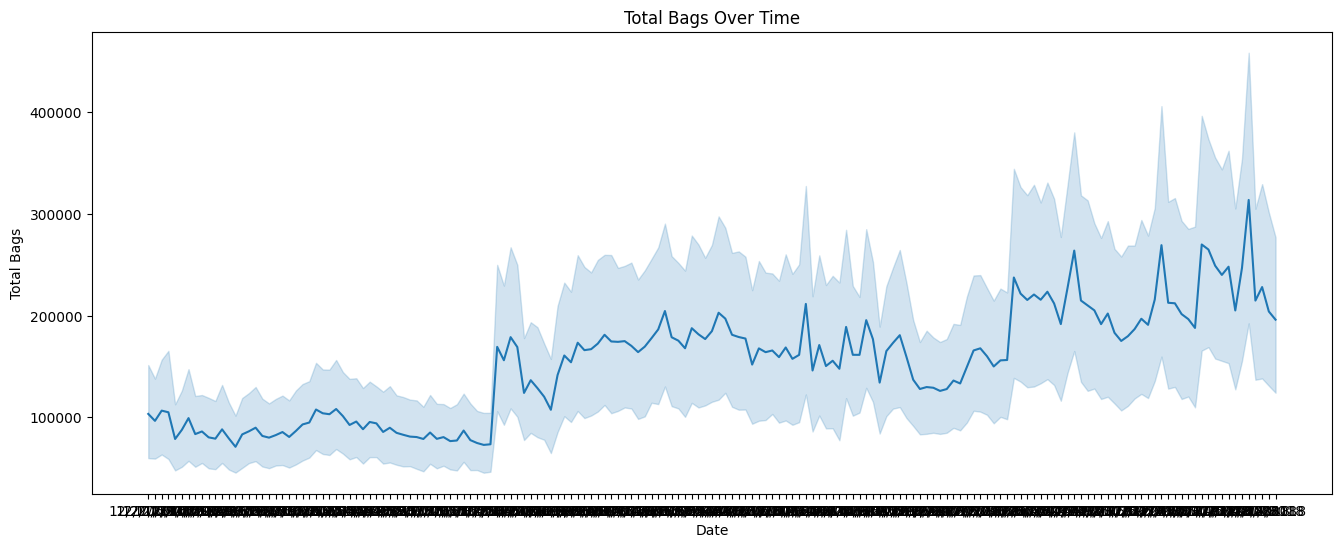

In [13]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="Date", y="Total Bags", data=df)
plt.title('Total Bags Over Time')
plt.xlabel('Date')
plt.ylabel('Total Bags')
plt.show()

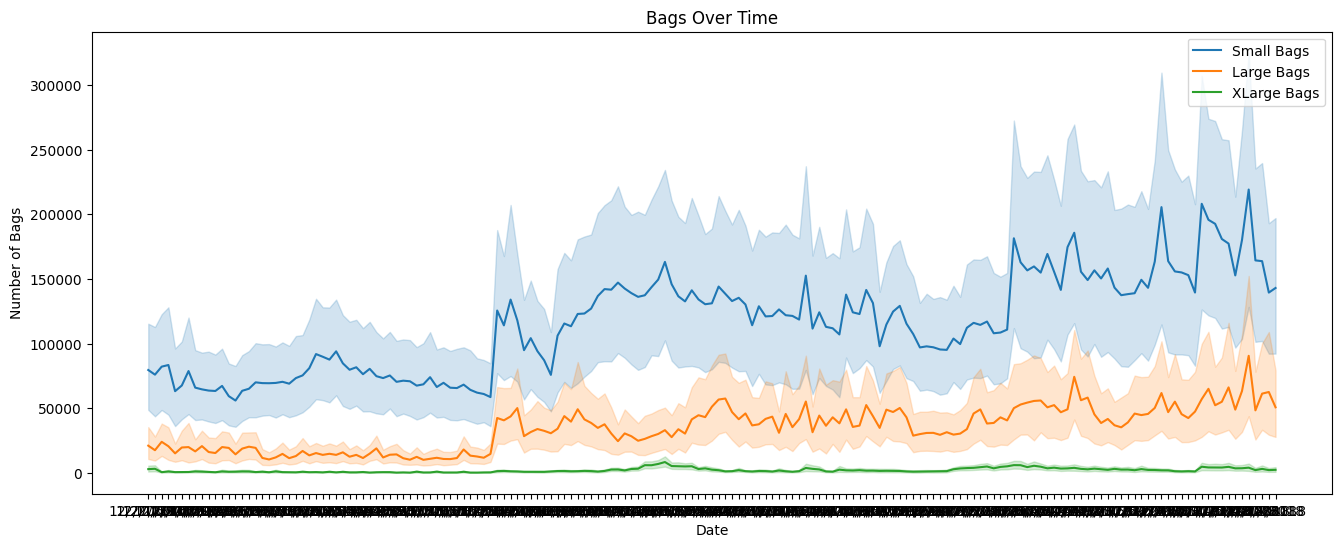

In [14]:
plt.figure(figsize=(16, 6))
sns.lineplot(x="Date", y="Small Bags", data=df, label="Small Bags")
sns.lineplot(x="Date", y="Large Bags", data=df, label="Large Bags")
sns.lineplot(x="Date", y="XLarge Bags", data=df, label="XLarge Bags")
plt.title('Bags Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Bags')
plt.legend()
plt.show()

In [15]:
fig = px.line(df, x="Date", y=["Small Bags", "Large Bags", "XLarge Bags"], title="Bags Over Time (Plotly)")
fig.show()

fig = px.line(df, x="Date", y="Total Bags", title='Total Bags Over Time (Plotly)')
fig.show()

# Case 2

Berdasarkan data avocado, tampilkan statistika deskriptif secara boxplot terkait penyebaran dari rata rata harga untuk masing-masing store (4046,4225,4770) dalam 1 layer, lalu interpretasikan hasil yang didapatkan dari visual tersebut.

In [44]:
df_melted = df.melt(id_vars=["AveragePrice", "year"],
                    value_vars=["4046", "4225", "4770"],
                    var_name="Product", value_name="Value")

df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

fig = px.box(df_melted,
             x="Product",
             y="Value",
             color="year",
             facet_col="Product",
             title="Boxplot of Value by Product and Year")

fig.show()

# Case 3

a. Hitunglah total bags setiap region setiap tahunnya<br>
b. Buatlah stacked bar chart total bags setiap region dalam 1 layout terhadap tahunnya

               region  Year   Total Bags
0              Albany  2015    719655.60
1              Albany  2016    838299.91
2              Albany  2017    835505.60
3              Albany  2018    286793.50
4             Atlanta  2015   2996990.87
..                ...   ...          ...
207              West  2018  38053293.04
208  WestTexNewMexico  2015   5528080.34
209  WestTexNewMexico  2016  11274737.15
210  WestTexNewMexico  2017  14797183.68
211  WestTexNewMexico  2018   3696514.36

[212 rows x 3 columns]


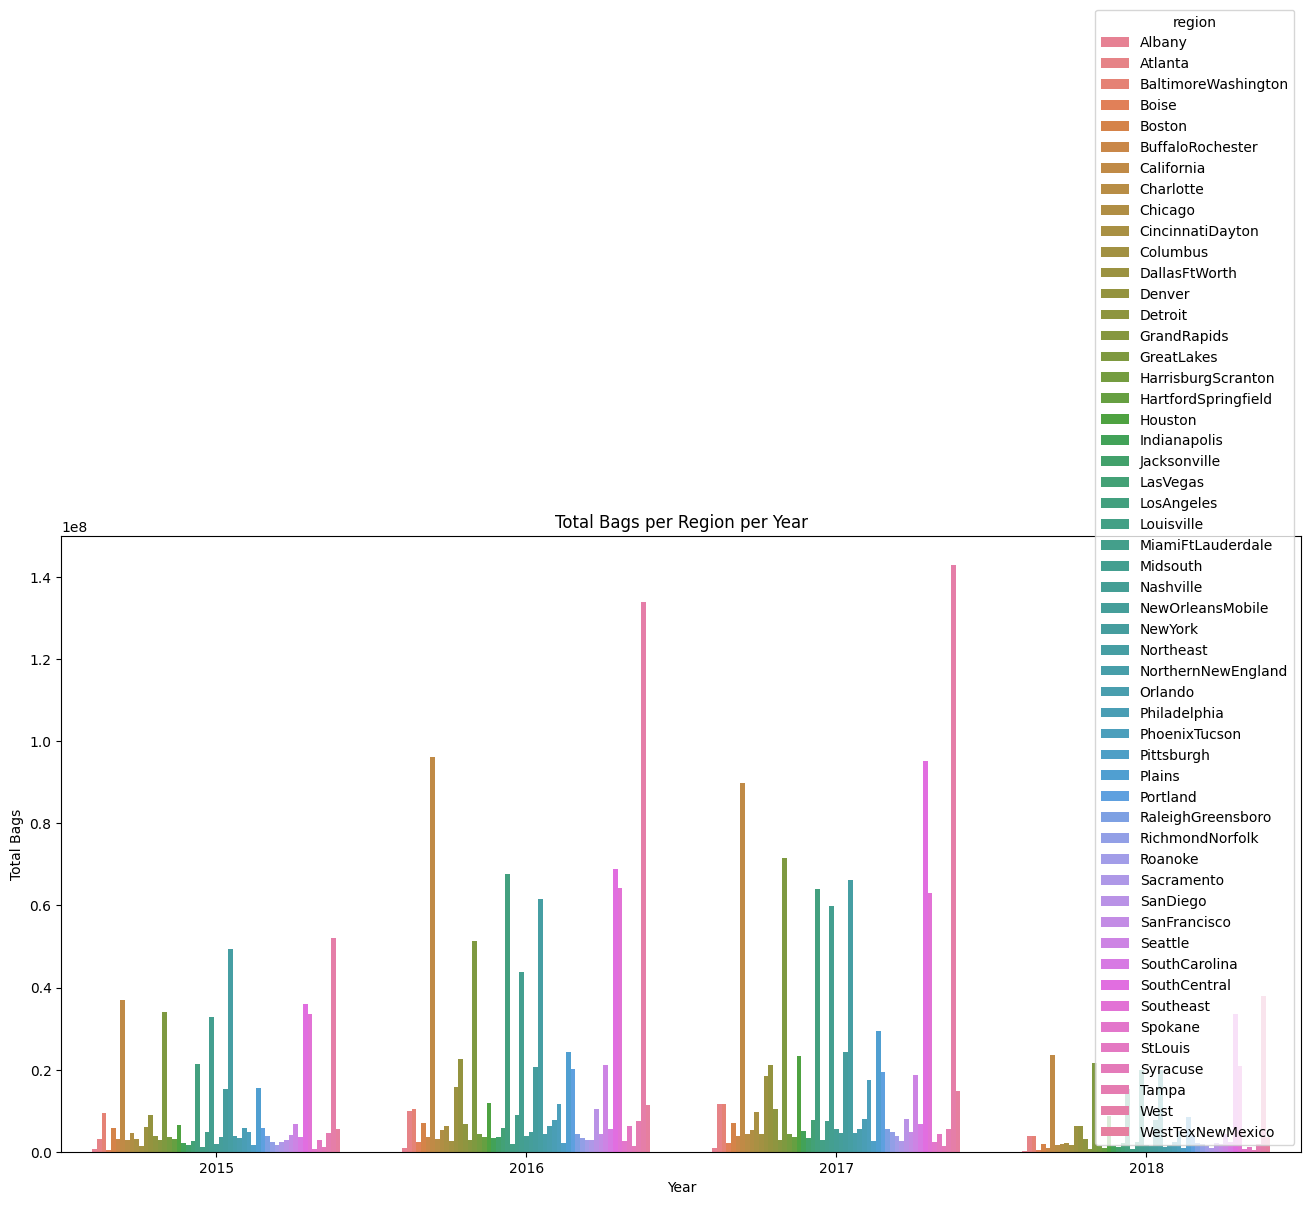

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year

total_bags_by_region_year = df.groupby(['region', 'Year'])['Total Bags'].sum().reset_index()

print(total_bags_by_region_year)


plt.figure(figsize=(16, 8))
sns.barplot(x='Year', y='Total Bags', hue='region', data=total_bags_by_region_year)
plt.title('Total Bags per Region per Year')
plt.xlabel('Year')
plt.ylabel('Total Bags')
plt.show()

In [26]:

fig = px.bar(total_bags_by_region_year, x='Year', y='Total Bags', color='region', title='Total Bags per Region per Year', barmode='stack')
fig.show()